# Customer Churn Analysis and Prediction

![Customer Churn Banner](Customer_churn_banner.png)

Customer churn is a major challenge for telecom companies because losing customers impacts revenue and increases customer acquisition costs.

This project analyzes customer behavior patterns and builds a machine learning model to predict customers likely to leave the company.

The project includes:
- Data cleaning and preprocessing
- Exploratory Data Analysis (EDA)
- Feature engineering
- Churn prediction using Machine Learning
- Model evaluation and business insights

The goal is to help businesses improve customer retention and reduce revenue loss.

## Importing Required Libraries
Imported Python libraries for data manipulation, visualization, machine learning model training, and performance evaluation.

In [31]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.ensemble import RandomForestClassifier

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

pd.set_option('display.max_columns', None)

## Loading the Dataset

The telecom customer churn dataset is loaded from a GitHub repository using Pandas. The first five rows are displayed to understand the dataset structure, customer details, billing information, service usage, and churn status.

In [32]:
url="https://raw.githubusercontent.com/RKYEngineering/customer-churn-analysis/refs/heads/main/data/WA_Fn-UseC_-Telco-Customer-Churn.csv"
df = pd.read_csv(url)

In [33]:
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Dataset Structure and Data Quality Check

The dataset structure, missing values, and statistical summaries are analyzed to better understand customer information, data types, and overall data quality before preprocessing and machine learning.

In [34]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [35]:
print(df.isnull().sum())


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [36]:
print(df.describe())

       SeniorCitizen       tenure  MonthlyCharges
count    7043.000000  7043.000000     7043.000000
mean        0.162147    32.371149       64.761692
std         0.368612    24.559481       30.090047
min         0.000000     0.000000       18.250000
25%         0.000000     9.000000       35.500000
50%         0.000000    29.000000       70.350000
75%         0.000000    55.000000       89.850000
max         1.000000    72.000000      118.750000


## Dataset Overview and Data Quality Check

The dataset contains 7,043 customer records and 21 features related to customer demographics, billing information, subscription services, and churn status.

The dataset structure, missing values, and statistical summaries are analyzed to understand data quality and identify important numerical features such as tenure and monthly charges before preprocessing and machine learning.

## Data Cleaning and Preprocessing

Before building the machine learning model, the dataset is cleaned and prepared for analysis.

- The `customerID` column is removed because it does not contribute to churn prediction.
- The `TotalCharges` column is converted into numerical format for accurate calculations and analysis.
- Missing values in `TotalCharges` are handled using the median value to maintain data consistency and improve model reliability.

Proper preprocessing helps improve data quality and ensures better machine learning performance.

In [37]:
# Remove customerID column
df.drop("customerID", axis=1, inplace=True)

# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

# Fill missing values
df["TotalCharges"] = df["TotalCharges"].fillna(
    df["TotalCharges"].median()
)

## Feature Engineering

New features are created to improve the machine learning model and better capture customer behavior patterns.



In [38]:
# Average charges per month
df["AvgChargesPerMonth"] = (
    df["TotalCharges"] / (df["tenure"] + 1)
)

# Tenure groups
df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 24, 48, 72],
    labels=[
        "0-1 Year",
        "1-2 Years",
        "2-4 Years",
        "4-6 Years"
    ]
)

## Customer Churn Distribution

The distribution of customer churn is visualized to understand how many customers stayed with the company and how many customers left.

This helps identify whether the dataset is balanced and provides an initial understanding of customer retention behavior.

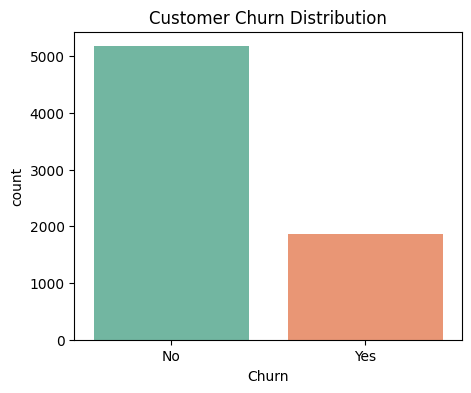

In [39]:
# Churn distribution
plt.figure(figsize=(5,4))

sns.countplot(
    x="Churn",
    hue="Churn",
    data=df,
    palette="Set2",
    legend=False
)

plt.title("Customer Churn Distribution")

plt.show()

Most customers stayed with the company, while fewer customers left.

This shows that customer retention is generally strong, but there is still a significant number of customers who churned. The dataset is slightly imbalanced because non-churn customers are much higher than churn customers, which is important to consider during model training and evaluation.

## Churn Analysis by Contract Type

Customer churn is analyzed across different contract types to understand how subscription duration affects customer retention.

This visualization helps identify which contract plans are associated with higher churn rates and provides insights into customer loyalty patterns.

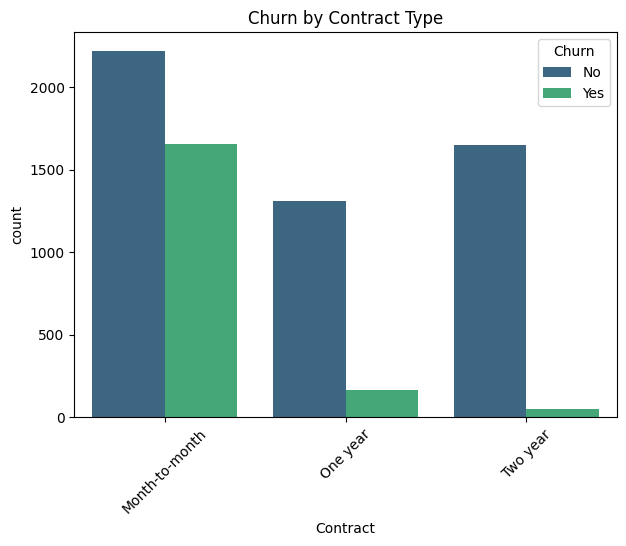

In [40]:
plt.figure(figsize=(7,5))

sns.countplot(
    x="Contract",
    hue="Churn",
    data=df,
    palette="viridis"
)

plt.xticks(rotation=45)

plt.title("Churn by Contract Type")

plt.show()


Customers with month-to-month contracts had the highest churn rates, while customers with long-term contracts showed significantly better retention. This suggests that contract stability plays an important role in reducing customer churn and improving customer loyalty.

## Monthly Charges Distribution

Visualized the distribution of monthly charges to understand customer spending patterns and pricing behavior.

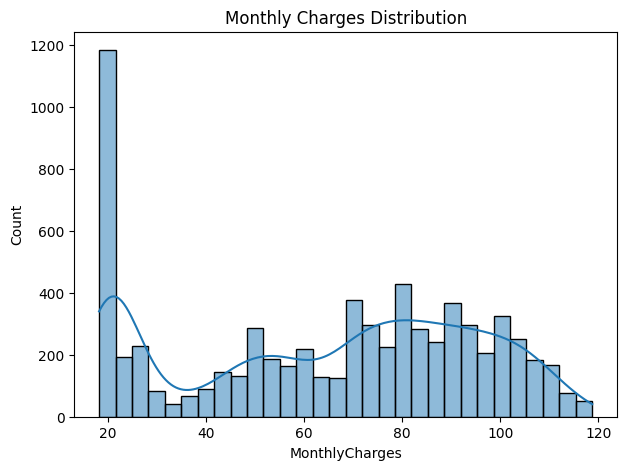

In [41]:
plt.figure(figsize=(7,5))

sns.histplot(
    df["MonthlyCharges"],
    bins=30,
    kde=True,

)

plt.title("Monthly Charges Distribution")

plt.show()

Customers use different service plans with different monthly costs. Customers paying higher monthly charges may leave the company more often because the service feels expensive. This means pricing can strongly affect customer churn.


## Correlation Analysis

Analyzed correlations between numerical features to identify relationships that may influence customer churn behavior.

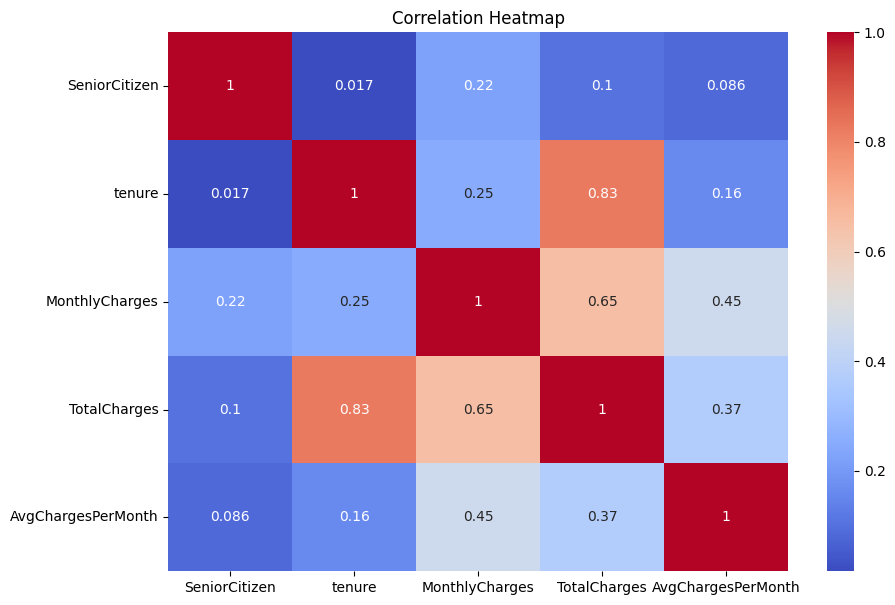

In [42]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,7))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

The correlation heatmap shows a strong positive relationship between tenure and total charges, indicating that long-term customers contribute more overall revenue. Monthly charges also showed moderate correlation with total charges, suggesting that pricing and subscription duration are important factors influencing customer value and retention behavior.


## Encoding Categorical Variables

Converted categorical customer information into numerical format using one-hot encoding so the machine learning model can process the data effectively.

In [43]:
df = pd.get_dummies(
    df,
    drop_first=True
)

## Feature and Target Selection

Separated the dataset into input features and target variable for customer churn prediction.

In [44]:
X = df.drop("Churn_Yes", axis=1)

y = df["Churn_Yes"]

## Train-Test Split

Split the dataset into training and testing sets to evaluate model performance on unseen customer data.

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Hyperparameter Configuration

Defined different Random Forest parameter combinations to optimize model performance using GridSearchCV.

In [46]:
params = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5]
}

grid = GridSearchCV(
    RandomForestClassifier(
        class_weight="balanced",
        random_state=42
    ),
    params,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:")
print(grid.best_params_)

Best Parameters:
{'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}


## Optimized Model Training

Selected the best-performing Random Forest model from GridSearchCV and trained it using the training dataset.

In [47]:
model = grid.best_estimator_

model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_split=5, n_estimators=200, random_state=42)

## Churn Prediction and Probability Estimation

Generated churn predictions and calculated churn probabilities for customers in the test dataset using the optimized Random Forest model.

In [48]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:,1]

## Model Performance Evaluation

Evaluated the optimized Random Forest model using accuracy score and classification metrics to measure churn prediction performance.

In [49]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:")
print(accuracy)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred
    )
)

Accuracy:
0.7920511000709723

Classification Report:
              precision    recall  f1-score   support

       False       0.91      0.80      0.85      1036
        True       0.58      0.77      0.66       373

    accuracy                           0.79      1409
   macro avg       0.74      0.79      0.76      1409
weighted avg       0.82      0.79      0.80      1409



The model achieved around 79% accuracy and performed well in identifying customer churn patterns. Higher recall for churned customers helps businesses identify at-risk customers and improve retention strategies.

## ROC-AUC Score Evaluation

Calculated the ROC-AUC score to evaluate the model’s ability to distinguish between churned and non-churned customers.

In [50]:
auc = roc_auc_score(
    y_test,
    y_prob
)

print("\nROC-AUC Score:")
print(auc)


ROC-AUC Score:
0.8636835322492159


The model achieved a high ROC-AUC score of 0.86, indicating strong ability to distinguish between churned and non-churned customers. This suggests the model is effective for identifying customers at risk of leaving the company.

## ROC Curve Visualization

Visualized the ROC curve to analyze the classification performance of the churn prediction model.

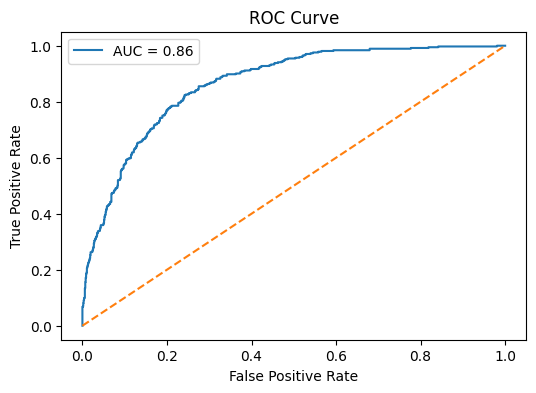

In [51]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(6,4))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc:.2f}"
)

plt.plot([0,1], [0,1], '--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

The ROC curve shows strong model performance with an AUC score of 0.86. The model can effectively distinguish between churned and non-churned customers, making it useful for identifying customers at high risk of leaving.

## Confusion Matrix Analysis

Visualized the confusion matrix to evaluate correct and incorrect churn predictions made by the model.

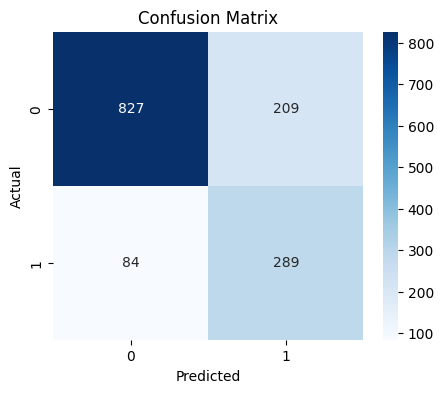

In [52]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

The confusion matrix shows that the model correctly identified many churned and non-churned customers. A smaller number of churned customers were missed, indicating the model is effective for supporting customer retention strategies.

## Feature Importance Analysis

Calculated feature importance scores to identify the most influential factors affecting customer churn prediction.

In [53]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(10))

                           Feature  Importance
1                           tenure    0.147574
3                     TotalCharges    0.115690
26               Contract_Two year    0.094526
4               AvgChargesPerMonth    0.087056
2                   MonthlyCharges    0.083852
11     InternetService_Fiber optic    0.060377
29  PaymentMethod_Electronic check    0.041551
33           TenureGroup_4-6 Years    0.037844
25               Contract_One year    0.031129
14              OnlineSecurity_Yes    0.027647


## Visualization of Important Features

Visualized the top features influencing customer churn using feature importance scores from the Random Forest model.

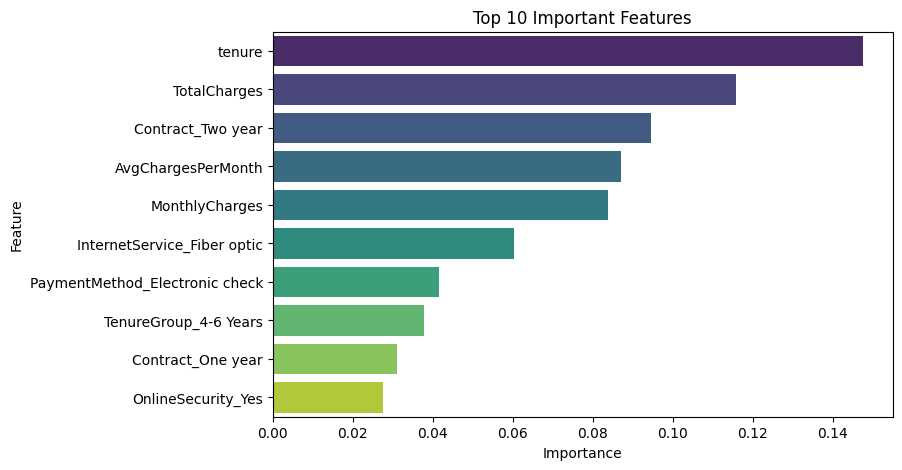

In [54]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance.head(10),
    palette="viridis",
    hue="Feature",
    legend=False
)

plt.title("Top 10 Important Features")

plt.show()

Customer tenure, billing patterns, and contract type were the strongest factors influencing customer churn. Long-term customers showed lower churn risk compared to short-term customers.

## Logistic Regression Model

Trained a Logistic Regression model to compare its performance with the Random Forest churn prediction model.

In [55]:
lr = LogisticRegression(
    max_iter=1000
)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("\nLogistic Regression Accuracy:")

print(
    accuracy_score(
        y_test,
        lr_pred
    )
)


Logistic Regression Accuracy:
0.8090844570617459


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


The Logistic Regression model achieved approximately 80.9% accuracy, showing competitive performance for customer churn prediction. This suggests that customer behavior and billing features are effective indicators of churn risk.

# Conclusion

This project analyzed customer behavior patterns and developed machine learning models to predict customer churn in the telecom industry.

Key findings from the analysis:
- Customers with month-to-month contracts had higher churn rates.
- Billing-related features such as monthly charges and total charges strongly influenced churn behavior.
- Long-term customers showed better retention compared to short-term customers.

The optimized Random Forest model achieved strong predictive performance with approximately 79% accuracy and a ROC-AUC score of 0.86, demonstrating effective churn prediction capability.

These insights can help businesses identify high-risk customers, improve retention strategies, and reduce potential revenue loss through data-driven decision-making.